# **MAT 4373: Project** </br> L1 vs. L2 regularization
Here we will be investigating the behaviour of regularization (L1 and L2 regularization) in the ideal theoretical space. Since this is our ideal space we assume that regularization will behave as expected, in fact we expect it to do quite well.

### **Dataset: An independent Gaussian design**
We generate synthetic data from a sparse linear model:

y = Xw* + ε

where:
- X ~ N(0, I), a design matrix with independent features,
- w* is sparse, with only s << d nonzero entries,
- ε ~ N(0, σ²), Gaussian noise.

**Goal**  
This dataset serves as a baseline under ideal conditions.  
We evaluate:
- prediction accuracy of Ridge and Lasso,
- parameter estimation accuracy,
- support recovery when the true model is sparse.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import learning_curve
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, recall_score
from sklearn.model_selection import train_test_split
from data_generation import generate_sparse_linear_data

#### **Experiment 1: Learning Curves**

We will greatly vary n (10, 50, 100, 200, 500) to see the different behaviours of the learning curve. All other variables will be unchanged in this experiment to simply observe the affect of n.


In [4]:
n_values = [10, 50, 100, 200, 500]

# baseline dataset generated using default parameter settings
datasets_size = {}

for n in n_values:
    X, y, w_true, non0 = generate_sparse_linear_data(n=n, d=50, s=5, sigma=1.0, signal=2.0,random_seeds=10)
    
    datasets_size[n] = {
        "X": X,
        "y": y,
        "w_true": w_true,
        "non0": non0
    }

for n in n_values:
    data = datasets_size[n]
    
    print(f"\n--- n = {n} ---")
    print("X shape:", data["X"].shape)
    print("y shape:", data["y"].shape)
    print("nonzero positions:", data["non0"])
    print("number of nonzero coefficients:", np.sum(data["w_true"] != 0))


--- n = 10 ---
X shape: (10, 50)
y shape: (10,)
nonzero positions: [32 18 47 46 21]
number of nonzero coefficients: 5

--- n = 50 ---
X shape: (50, 50)
y shape: (50,)
nonzero positions: [ 8 24  1 21  6]
number of nonzero coefficients: 5

--- n = 100 ---
X shape: (100, 50)
y shape: (100,)
nonzero positions: [ 0  8 48 36 47]
number of nonzero coefficients: 5

--- n = 200 ---
X shape: (200, 50)
y shape: (200,)
nonzero positions: [21 22 17 27 19]
number of nonzero coefficients: 5

--- n = 500 ---
X shape: (500, 50)
y shape: (500,)
nonzero positions: [47  4 26 46 37]
number of nonzero coefficients: 5


c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.256e-01, tolerance: 1.204e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.845e-01, tolerance: 1.204e-01
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

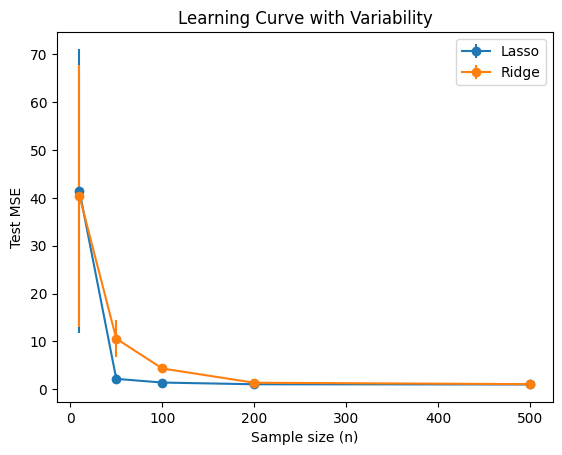

In [6]:
num_trials = 10

results = {
    "n": [],
    "lasso_mean": [],
    "lasso_std": [],
    "ridge_mean": [],
    "ridge_std": []
}

for n in n_values:
    data = datasets_size[n]
    lasso_errors = []
    ridge_errors = []
    
    for seed in range(num_trials):
        X_train, X_test, y_train, y_test = train_test_split(
            data["X"], data["y"], test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_errors.append(mean_squared_error(y_test, lasso.predict(X_test)))
        
        # Ridge
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train, y_train)
        ridge_errors.append(mean_squared_error(y_test, ridge.predict(X_test)))
    
    results["n"].append(n)
    results["lasso_mean"].append(np.mean(lasso_errors))
    results["lasso_std"].append(np.std(lasso_errors))
    results["ridge_mean"].append(np.mean(ridge_errors))
    results["ridge_std"].append(np.std(ridge_errors))

plt.errorbar(results["n"], results["lasso_mean"],
             yerr=results["lasso_std"], marker='o', label="Lasso")

plt.errorbar(results["n"], results["ridge_mean"],
             yerr=results["ridge_std"], marker='o', label="Ridge")

plt.xlabel("Sample size (n)")
plt.ylabel("Test MSE")
plt.title("Learning Curve with Variability")
plt.legend()
plt.show()

MSE done over multiple times (10 times) to average out results and then plot results. Lasso does better over a smaller sample size but at the end lasso and ridge do similarly. Lasso does well in sparse settings

#### **Experiment 2: Effects of Sparsity on penalty terms**

We will compare sparsity and lambda to see how our models do under a sparsity condition and how almbda will adjust. All other variables will be unchanged. 

In [7]:
sparsity_values = [5, 10, 50, 99]

# baseline dataset generated using default parameter settings
datasets_sparsity = {}

for sparsity in sparsity_values:
    X, y, w_true, non0 = generate_sparse_linear_data(n=100, d=100, s=sparsity, sigma=1.0, signal=2.0,random_seeds=20)
    
    datasets_sparsity[sparsity] = {
        "X": X,
        "y": y,
        "w_true": w_true,
        "non0": non0
    }

for s in sparsity_values:
    data = datasets_sparsity[s]
    
    print(f"\n--- s = {s} ---")
    print("X shape:", data["X"].shape)
    print("y shape:", data["y"].shape)
    print("nonzero positions:", data["non0"])
    print("number of nonzero coefficients:", np.sum(data["w_true"] != 0))


--- s = 5 ---
X shape: (100, 100)
y shape: (100,)
nonzero positions: [24 39  4 96 20]
number of nonzero coefficients: 5

--- s = 10 ---
X shape: (100, 100)
y shape: (100,)
nonzero positions: [38  4 23 54 37 88 18 91 78  0]
number of nonzero coefficients: 10

--- s = 50 ---
X shape: (100, 100)
y shape: (100,)
nonzero positions: [65 40 27 60 43 10 12 30 47 54 35  8 11 22 89 63 44  0 83  2 70 92 51 39
 53 21 50 34 78 29 18 20 76 96 90 75 52 38 13 73 23 32 26  6 42 14 72 64
 61 49]
number of nonzero coefficients: 50

--- s = 99 ---
X shape: (100, 100)
y shape: (100,)
nonzero positions: [81 99 75 14 19 65  2 48 31 36 88 27 49 33  9 72 97 11 34 44  3 86 57 46
 50 80 10 59 66 40 67 18 83 47 73 91  8 20 79 29 62 58 51 23 96 53 15 69
 63 64 21 89  5 54 32 38 85 39 94 37 93 16  7 87 98 71  0 92 25 77 12 84
 55 78 35 70 61 95 22  4 41 13 82 68  1 42 28 30 90 56 17 45 76 60 26 43
 74 24  6]
number of nonzero coefficients: 99


c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.181e+00, tolerance: 3.131e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.532e+00, tolerance: 3.131e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

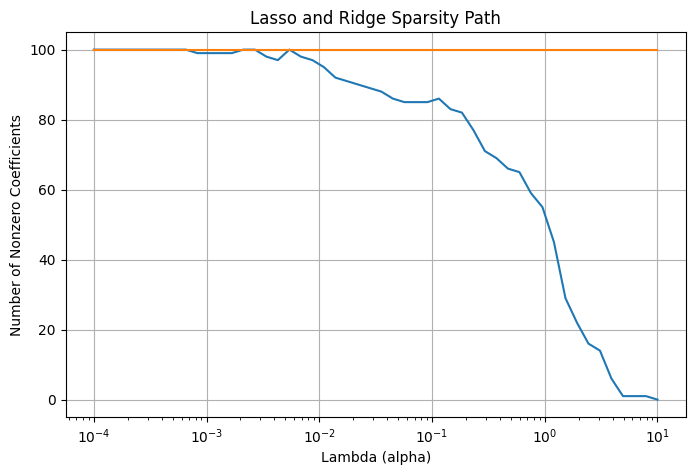

In [8]:

lasso_nonzero = []
ridge_nonzero = []
alphas = np.logspace(-4, 1, 50)  # from 0.0001 to 10
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)

    ridge = Ridge(alpha=alpha)
    ridge.fit(X, y)
    
    # count nonzero coefficients (choose 1e^-6 as threshold to account for numerical precision, assumes anything smaller is effectively zero)
    lasso_non_zero = np.sum(np.abs(lasso.coef_) > 1e-6)
    lasso_nonzero.append(lasso_non_zero)

    ridge_non_zero = np.sum(np.abs(ridge.coef_) > 1e-6)
    ridge_nonzero.append(ridge_non_zero)


plt.figure(figsize=(8, 5))
plt.plot(alphas, lasso_nonzero, label="Lasso")
plt.plot(alphas, ridge_nonzero, label="Ridge")

plt.xscale('log')
plt.xlabel("Lambda (alpha)")
plt.ylabel("Number of Nonzero Coefficients")
plt.title("Lasso and Ridge Sparsity Path")

plt.grid(True)
plt.show()

Ridge never has any coefficients that are 0, even as alpha increases. Lasso has coefficients that go to 0, as alpha gets larger more coefficients go to 0 (larger penalty). We can also look at the performance of these models.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.390e+00, tolerance: 1.210e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.306e+00, tolerance: 1.198e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

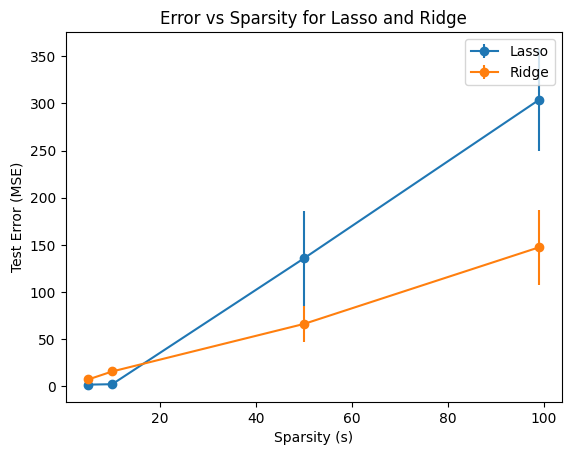

In [9]:
num_trials = 10

results = {
    "s": [],
    "lasso_mse": [],
    "lasso_std": [],
    "ridge_mse": [],
    "ridge_std": []
}

for sparsity in sparsity_values:
    data = datasets_sparsity[sparsity]
    lasso_errors = []
    ridge_errors = []
    
    for seed in range(num_trials):
        X_train, X_test, y_train, y_test = train_test_split(
            data["X"], data["y"], test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_y_pred = lasso.predict(X_test)
        lasso_errors.append(mean_squared_error(y_test, lasso_y_pred))
        
        # Ridge
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train, y_train)
        ridge_errors.append(mean_squared_error(y_test, ridge.predict(X_test)))

    results["s"].append(sparsity)
    results["lasso_mse"].append(np.mean(lasso_errors))
    results["lasso_std"].append(np.std(lasso_errors))
    results["ridge_mse"].append(np.mean(ridge_errors))
    results["ridge_std"].append(np.std(ridge_errors))

plt.errorbar(results["s"], results["lasso_mse"],
             yerr=results["lasso_std"], marker='o', label="Lasso")

plt.errorbar(results["s"], results["ridge_mse"],
             yerr=results["ridge_std"], marker='o', label="Ridge")

plt.xlabel("Sparsity (s)")
plt.ylabel("Test Error (MSE)")
plt.title("Error vs Sparsity for Lasso and Ridge")
plt.legend()
plt.show()

Lasso does better with less sparse models , while ridge regression does considerably better for very sparse models.

#### **Experiment 3: The effects of training sizes**

At the recall of our regularization models. We will vary the size of the training set and guage how well our model is doing in each of those cases.

c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.032e-03, tolerance: 4.762e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.344e-03, tolerance: 3.071e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\sophs\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

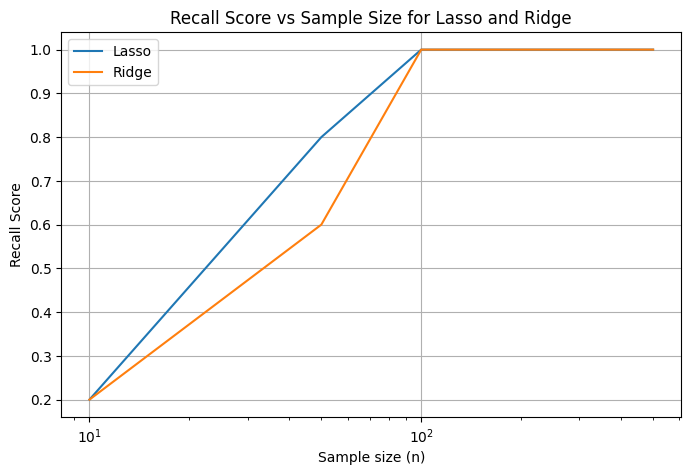

In [10]:
num_trials = 10

results = {
    "n": [],
    "lasso_recall": [],
    "ridge_recall": []
}

threshold = 1e-3 #threshold to determine nonzero coefficients for recall calculation 

for n in n_values:
    for seed in range(num_trials):
        X, y, w_true, non0 = generate_sparse_linear_data(n=n, d=50, s=5, sigma=1.0, signal=0.5,random_seeds=seed)

        true_support = np.zeros(len(w_true), dtype=int)
        true_support[non0] = 1
    
        lasso_recalls = []
        ridge_recalls = []
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=seed
        )
        
        # Lasso
        lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        lasso.fit(X_train, y_train)
        lasso_support = (lasso.coef_ != 0).astype(int)
        lasso_recalls.append(recall_score(true_support, lasso_support))
        
        # Ridge
        ridge = RidgeCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1, 10])
        ridge.fit(X_train, y_train)
        k = len(non0)
        ridge_support = np.zeros_like(ridge.coef_)
        top_k = np.argsort(np.abs(ridge.coef_))[-k:]
        ridge_support[top_k] = 1
        ridge_recalls.append(recall_score(true_support, ridge_support))

    results["n"].append(n)
    results["lasso_recall"].append(np.mean(lasso_recalls))
    results["ridge_recall"].append(np.mean(ridge_recalls))

plt.figure(figsize=(8, 5))
plt.plot(results["n"], results["lasso_recall"], label="Lasso")
plt.plot(results["n"], results["ridge_recall"], label="Ridge")

plt.xscale('log')
plt.xlabel("Sample size (n)")
plt.ylabel("Recall Score")
plt.title("Recall Score vs Sample Size for Lasso and Ridge")

plt.legend()
plt.grid(True)
plt.show()


Lasso does better in smaller datasets since it can adjust to sparsity but they both improve. **keep in mind ridge is being artificially boosted currently by picking the top k coefficients to compare to the k coefficients of lasso.